# Companion search with CANDID & Pymask

In [1]:
from astropy.io import fits
from matplotlib import pyplot as plt

import amical

In this tutorial, we will show how to go from a calibrated `.oifits` file to posterior estimates of binary parameters, using two different packages for parameter inference:

- [CANDID](https://github.com/amerand/CANDID), developed by [Antoine Merand](https://github.com/amerand) & Alexandre Gallenne, and
- [Pymask](https://github.com/AnthonyCheetham/pymask), developed by [Benjamin Pope](https://github.com/benjaminpope) & [Anthony Cheetham](https://github.com/AnthonyCheetham).

With AMICAL, we provide some easy interface between these codes and the outputs
of our extraction pipeline. We give below some example to analyze and
extract the quantitative values of a simulated binary.

## OIFITS data of the simulated binary

We will use the calibrated observable of a simulated NIRISS AMI binary observation.
The OIFITS file can be generated by following the [NIRISS extraction tutorial](../niriss-extraction/).

In [2]:
inputdata = "Saveoifits/example_fakebinary_NIRISS.oifits"

hdul = fits.open(inputdata)
hdul.info()
hdul.close()

Filename: Saveoifits/example_fakebinary_NIRISS.oifits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      18   ()      
  1  OI_WAVELENGTH    1 BinTableHDU     17   1R x 2C   [1E, 1E]   
  2  OI_TARGET     1 BinTableHDU     56   1R x 17C   [1I, 16A, 1D, 1D, 1E, 1D, 1D, 1D, 8A, 8A, 1D, 1D, 1D, 1D, 1E, 1E, 16A]   
  3  OI_ARRAY      1 BinTableHDU     32   7R x 7C   [16A, 16A, 1I, 1E, 3D, 1D, 6A]   
  4  OI_VIS2       1 BinTableHDU     38   21R x 10C   [1I, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 2I, 1L]   
  5  OI_T3         1 BinTableHDU     50   35R x 14C   [1I, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 3I, 1L]   


As we can see above, an OIFITS is just a FITS file with extensions that are specific to interferometric observables.
AMICAL has all the functionality you need to read these files directly.

## CANDID analysis

### Companion search

The CANDID module can perform a grid search for binary companions.
We first have to initialize the parameters for the grid search.

In [3]:
param_candid = {
    "rmin": 20,  # inner radius of the grid
    "rmax": 250,  # outer radius of the grid
    "step": 50,  # grid sampling
    "ncore": 1,  # core for multiprocessing
}

It will search on a grid defined in circles from `rmin` to `rmax` (in milliarcseconds), with step size `step`.
The code supports multiprocessing but we set it to a single core here.
If you want to save the figure locally as .pdf, use `save=True`.


 | --- Start CANDID fitting --- :

 | loading file Saveoifits/example_fakebinary_NIRISS.oifits
 | observables available: [ 'cp', 'v2', 't3']
 | instruments: [ 'NIRISS']
 | best fit diameter (UD): 13.433 +- 1.171 mas (χ2 = 191.346)
 | Grid Fitting on 74 starting points (single processor) ... (it should take about 0 seconds)
 [========================================================    ] 94%,     0 s (remaining)
 | Grid of fit took 1.2 seconds
 | current grid step (50.00mas) is too fine!!! --> 100.00mas should be enough


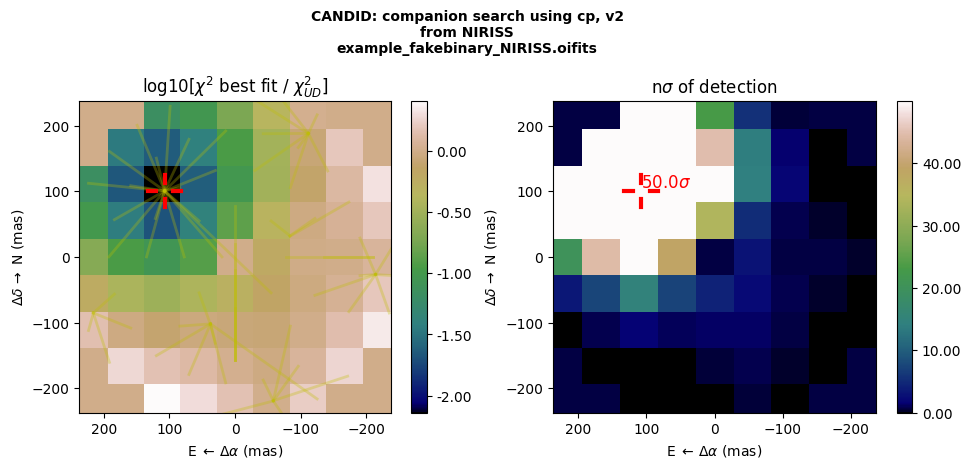

Results binary fit (χ2 = 1.1, nσ = 50.0):
-------------------

Sep = 147.1 +/- 0.7 mas
Theta = 46.9 +/- 0.3 deg
CR = 247.1 +/- 2.5
dm = 5.98 +/- 0.01


In [4]:
fit1 = amical.candid_grid(inputdata, **param_candid, diam=20, doNotFit=[], save=False)

As we see here there is a very clear detection of the companion.

Let us now take a look at the best fit model compared to the data.

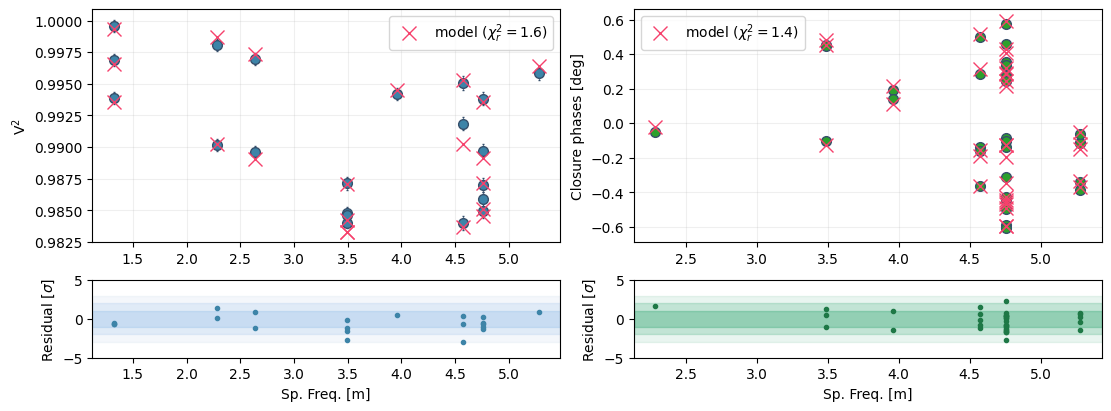

In [5]:
_ = amical.plot_model(inputdata, fit1["best"], save=False)

### Contrast limits

We can also estimate contrast limits for non-detections.

To do this in CANDID, we Monte Carlo over the errors in the `oifits` data
to estimate, in the absence of bias, the fraction of false positives
that would be contributed purely by independent, identically distributed noise.
Note that this can be quite different from the results of an end-to-end
injection-recovery test, which can probe bias and correlated noise!

 | --- Start CANDID contrast limit --- :

 | loading file Saveoifits/example_fakebinary_NIRISS.oifits
 | observables available: [ 'cp', 'v2', 't3']
 | instruments: [ 'NIRISS']
 | observables: ['cp', 'v2'] from ['cp', 'v2', 't3']
 | instruments: ['NIRISS'] from ['NIRISS']
 | best fit diameter (UD): 2.218 +- 0.517 mas (χ2 = 1.034)
 | Detection Limit Map 10x10 (single processor) ... it should take about 3 seconds
 | Method: injection
 [============================================================] 100%,     0 s (remaining)


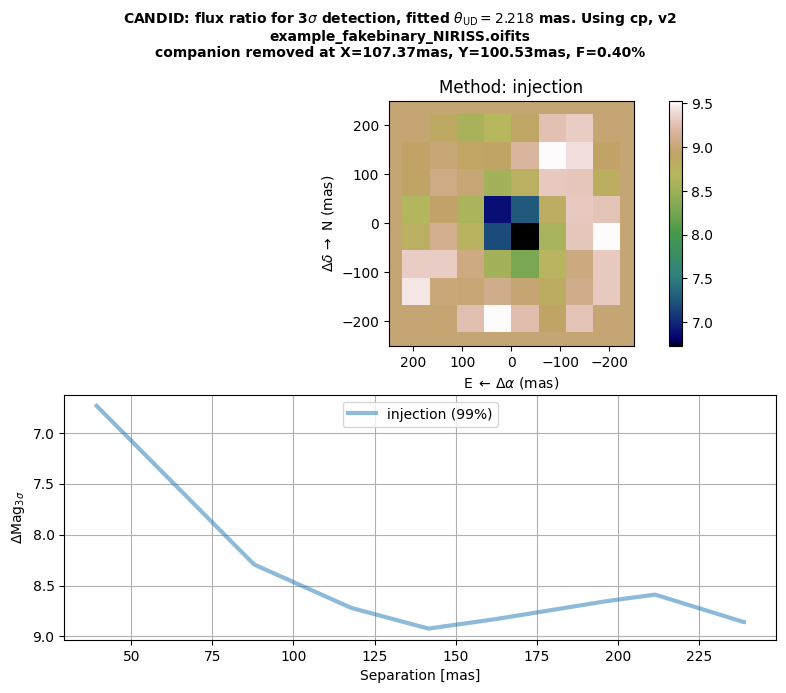

In [6]:
cr_candid = amical.candid_cr_limit(
    inputdata, **param_candid, fitComp=fit1["comp"], save=False
)

## Bayesian Inference with Pymask

Pymask is complementary to CANDID and provides an interface to estimate
model parameters through Bayesian inference.
To do so, we need priors in separation, position angle and contrast,
as well as flags for multiprocessing, and additional error.

Pymask proposes to add some `extra_error_cp` on the CP.
This allows to take into account a possibly underestimated uncertainties on the data.
Indeed, some bias due to mismatch between the calibrator and the science spectral type,
or some systematic temporal effect could produce additional errors not properly retrieved by the covariance matrix.

In addition, we can also add some scaling parameter (`err_scale`)
on the CP uncertainties to deal with the number of independent closure phases,
which is the number of linearly independent triangles ($N(N-1)(N-2)/6$),
and is smaller than simply the set of triangles ($(N-1)(N-2)/2$).
If you consider the full CP set (35 for a 7 holes mask), you double count your data,
so you have to scale your uncertainties by the factor of additional CP, which is $\sqrt{N/3}$.

Note that if you used only a subset of CP (by selecting one common hole to save the OIFITS, see [amical.save()](../../api/amical/oifits/#amical.oifits.save) for details), this additional `err_scale` is unusable.

In [7]:
param_pymask = {
    "sep_prior": [100, 180],  # Prior on the separation
    "pa_prior": [20, 80],  # Prior on the position angle
    "cr_prior": [230, 270],  # Prior on the contrast ratio
    "ncore": 1,  # core for multiprocessing
    "extra_error_cp": 0,
    "err_scale": 1,
}

### Grid search

Now we can do a grid search followed by local optimization, which proceeds similarly to CANDID:

PYMASK - 1 oifits loaded : n=1x35=35 closure phases.


Maximum likelihood estimation (χ2=1.2):
-------------------------------
Separation = 147.18 mas
PA = 46.15 deg
Contrast Ratio = 246.4 (6.0 mag)



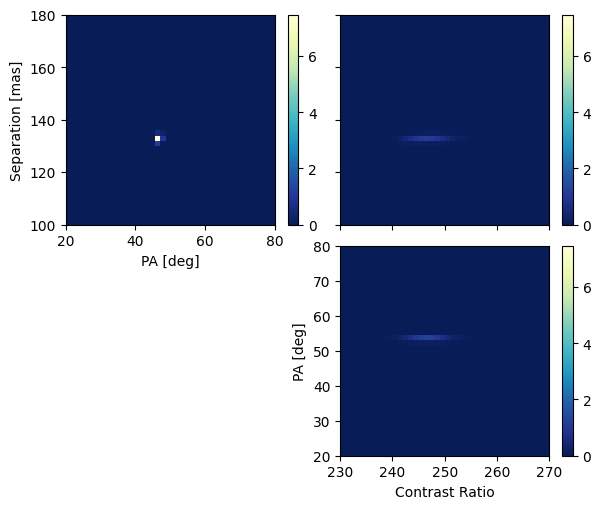

In [8]:
fit2 = amical.pymask_grid(inputdata, **param_pymask)

The main reason to use Pymask is its interface to Bayesian inference tools like nested sampling and MCMC.
Here, let's use MCMC from [emcee](https://emcee.readthedocs.io/en/stable/) to infer proper Bayesian posteriors for the binary parameters.

PYMASK - 1 oifits loaded : n=1x35=35 closure phases.

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:03<00:00, 205.43it/s]


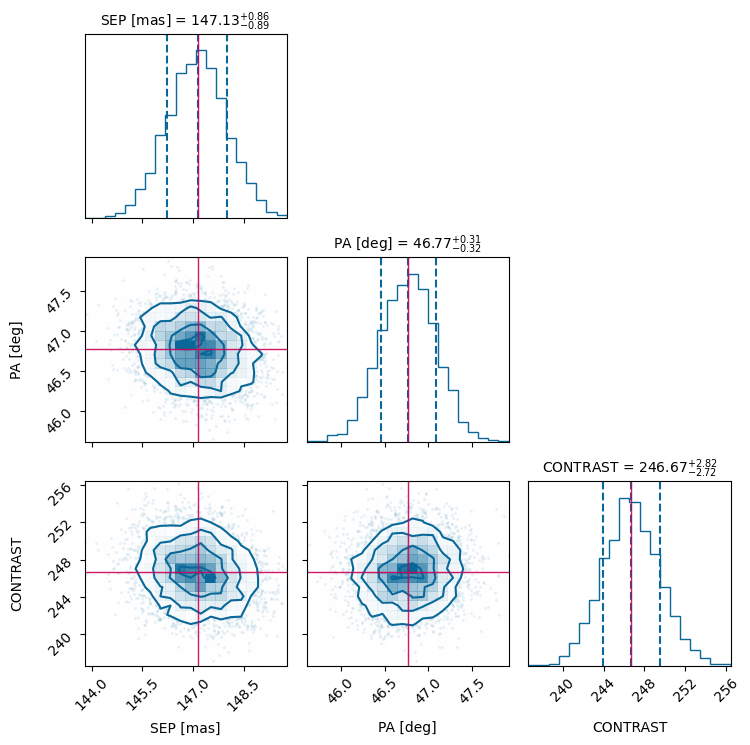

MCMC estimation
---------------
Separation = 147.1 +0.9/-0.9 mas
PA = 46.8 +0.3/-0.3 deg
Contrast Ratio = 246.7 +2.8/-2.7
dm = 5.98 +0.01/-0.01 mag


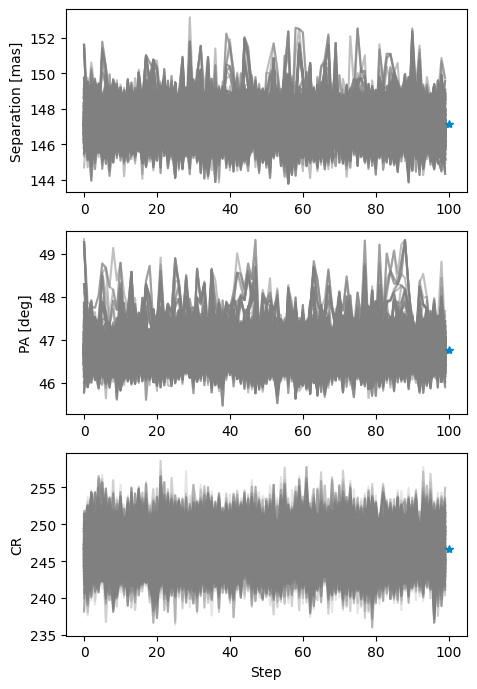

In [9]:
param_mcmc = {
    "niters": 800,
    "walkers": 100,
    "initial_guess": [146, 47, 244],
    "burn_in": 100,
}

fit3 = amical.pymask_mcmc(inputdata, **param_pymask, **param_mcmc)

As with CANDID, we can also Monte Carlo over the error bars to estimate limits for non-detections.
Note that the same caveat applies that this is no substitute for proper end-to-end injection-recovery simulations.

In [10]:
cr_pymask = amical.pymask_cr_limit(
    inputdata,
    nsim=500,
    ncore=1,
    smax=250,
    nsep=100,
    cmax=5000,
    nth=30,
    ncrat=60,
)

PYMASK - 1 oifits loaded : n=1x35=35 closure phases.

Detection limit resolution: 0.006666666666666667 %
(35, 1, 500) (35, 1)
Setting up the big dictionary to store variables for loop
Starting big loop over separations
Total time elapsed: 19.133280754089355 seconds


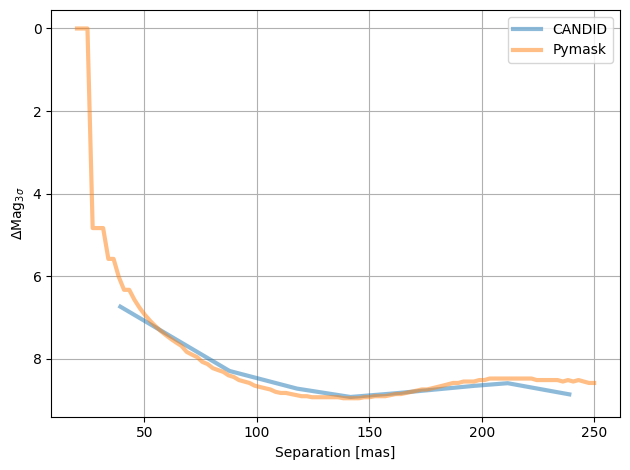

In [11]:
plt.figure()
plt.plot(cr_candid["r"], cr_candid["cr_limit"], label="CANDID", alpha=0.5, lw=3)
plt.plot(cr_pymask["r"], cr_pymask["cr_limit"], label="Pymask", alpha=0.5, lw=3)
plt.ylim(plt.ylim()[1], plt.ylim()[0])  # -- reverse plot
plt.xlabel("Separation [mas]")
plt.ylabel(r"$\Delta \mathrm{Mag}_{3\sigma}$")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()